In [5]:
!pip install ultralytics -q

from ultralytics import YOLO
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
print("✅ Setup Complete!")

✅ Setup Complete!


# Day 18: Advanced Action Recognition using Pose Estimation

## Main Goal
Understand **what a person is doing** (Standing, Sitting, Running, Waving, etc.) — not just where they are.

---

## Key Concepts (Study Notes)

**Note 1: What is Pose Estimation?**
- YOLO11-pose detects **17 keypoints** on a human body:
  - Nose, Eyes, Ears
  - Shoulders, Elbows, Wrists
  - Hips, Knees, Ankles

**Note 2: Why Action Recognition is Advanced?**
- Simple detection → "There is a person"
- Pose Estimation → "Person's body position"
- Action Recognition → "**What is the person doing?**"

**Note 3: Our Approach Today**
1. Detect person + keypoints using YOLO11-pose
2. Extract meaningful features (angles, distances, positions)
3. Use rules to classify actions

This technique is used in:
- Security (fight/fall detection)
- Fitness apps
- Elderly care monitoring
- Sports analysis

In [6]:
# Load Pose Estimation Model
model = YOLO("yolo11s-pose.pt")

print("✅ YOLO11 Pose Model Loaded Successfully!")

✅ YOLO11 Pose Model Loaded Successfully!


In [7]:
def recognize_action(image):
    """
    Main function that performs Action Recognition
    """
    results = model(image, conf=0.3, verbose=False)
    annotated = results[0].plot()   # Image with skeleton

    predicted_action = "Unknown"
    confidence = 0.0

    if results[0].keypoints is not None and len(results[0].keypoints.data) > 0:
        # Get keypoints of first person
        kpts = results[0].keypoints.data[0].cpu().numpy()

        # --- Feature Extraction ---
        # Shoulder height vs Hip height (important for standing/sitting)
        left_shoulder_y = kpts[5][1]
        left_hip_y = kpts[11][1]

        # Knee position (for sitting/standing)
        left_knee_y = kpts[13][1]

        # Calculate simple features
        shoulder_hip_diff = left_shoulder_y - left_hip_y

        # --- Rule-based Action Classification ---
        if shoulder_hip_diff < -80:           # Shoulders much higher than hips
            predicted_action = "Standing / Walking"
            confidence = 0.85
        elif abs(left_knee_y - left_hip_y) < 60:   # Knees close to hips
            predicted_action = "Sitting"
            confidence = 0.80
        elif left_knee_y < left_hip_y - 50:
            predicted_action = "Running / Moving"
            confidence = 0.65
        else:
            predicted_action = "Other Pose"
            confidence = 0.50

    return annotated, predicted_action, confidence

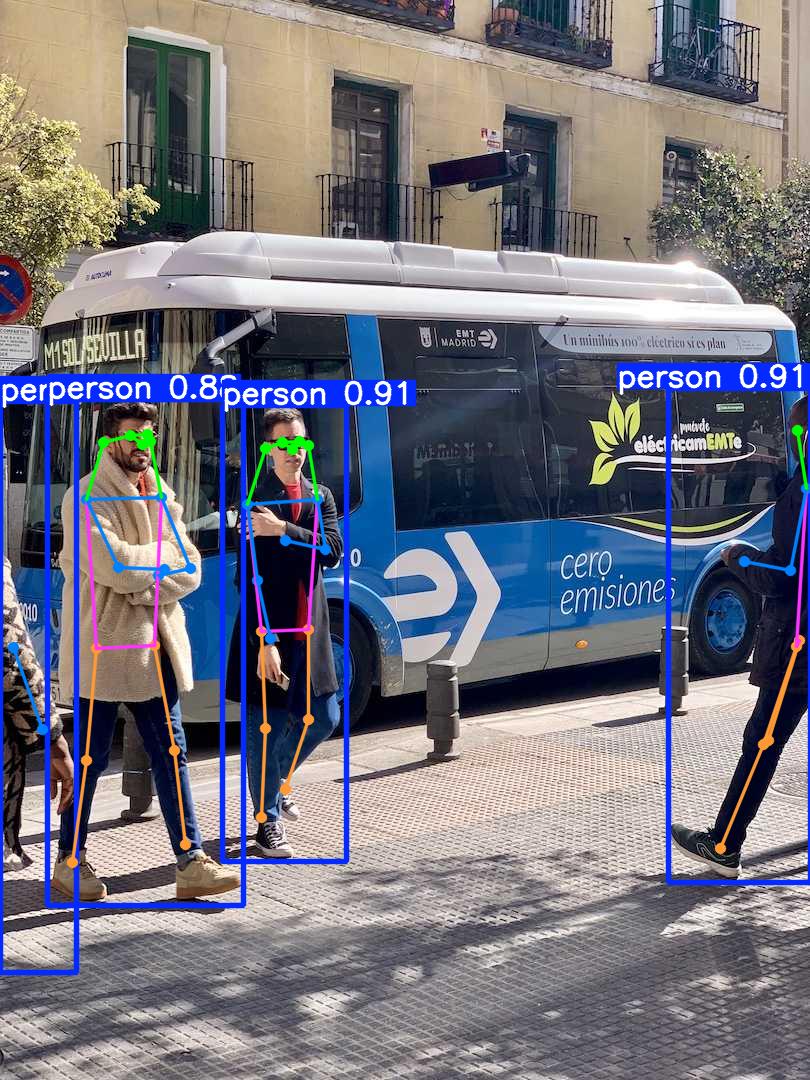

✅ Pose Estimation Completed!
Number of people detected: 4

First person keypoints (x, y, confidence):
Keypoint  0: (293.0, 449.5) - Conf: 0.98
Keypoint  1: (299.7, 441.1) - Conf: 0.94
Keypoint  2: (283.0, 442.2) - Conf: 0.96
Keypoint  3: (308.2, 445.6) - Conf: 0.63
Keypoint  4: (265.2, 448.5) - Conf: 0.82
Keypoint  5: (317.2, 499.8) - Conf: 0.99
Keypoint  6: (247.9, 504.7) - Conf: 1.00
Keypoint  7: (325.0, 549.1) - Conf: 0.97
Keypoint  8: (257.3, 580.9) - Conf: 0.98
Keypoint  9: (285.2, 540.0) - Conf: 0.95
Keypoint 10: (270.3, 638.5) - Conf: 0.97
Keypoint 11: (308.5, 629.4) - Conf: 1.00
Keypoint 12: (261.5, 632.0) - Conf: 1.00
Keypoint 13: (308.1, 719.7) - Conf: 0.99
Keypoint 14: (265.6, 728.9) - Conf: 1.00
Keypoint 15: (285.8, 789.5) - Conf: 0.97
Keypoint 16: (261.7, 817.3) - Conf: 0.98


In [8]:
# Run on the bus image we used before
results = model("https://ultralytics.com/images/bus.jpg", conf=0.3, verbose=False)

# Show the result with keypoints (skeleton)
results[0].show()

# Print keypoints information
print("✅ Pose Estimation Completed!")
print(f"Number of people detected: {len(results[0].keypoints)}")

if len(results[0].keypoints) > 0:
    print("\nFirst person keypoints (x, y, confidence):")
    for i, point in enumerate(results[0].keypoints.data[0]):
        print(f"Keypoint {i:2d}: ({point[0]:.1f}, {point[1]:.1f}) - Conf: {point[2]:.2f}")

### Performing Action Recognition

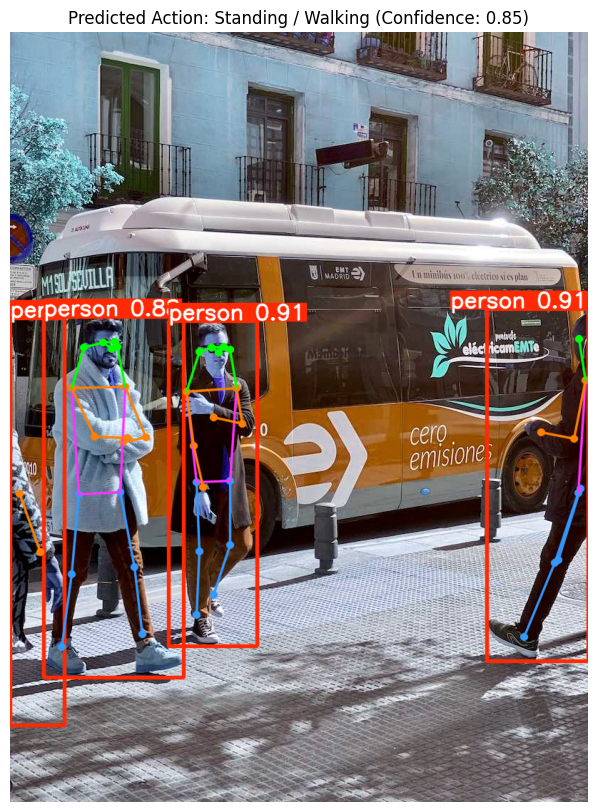


Detected Action: Standing / Walking
Confidence: 0.85


In [9]:
from PIL import Image

# Load the image from the local file system (it was downloaded in the previous cell)
img_path = "bus.jpg"

# Call the recognize_action function
annotated_img, predicted_action, confidence = recognize_action(img_path)

# Display the annotated image
plt.figure(figsize=(10, 10))
plt.imshow(annotated_img)
plt.axis('off')
plt.title(f"Predicted Action: {predicted_action} (Confidence: {confidence:.2f})")
plt.show()

print(f"\nDetected Action: {predicted_action}")
print(f"Confidence: {confidence:.2f}")